<a href="https://colab.research.google.com/github/Love1117/Machine_learning-Projects/blob/main/Machine_Learning%20Project/03_Deep%20Learning%20Projects/Transfer%20Learning/Fine-tune%20MobileNetV2/classifier_model/My_Image_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Importing needed libries**

In [45]:
from google.colab import drive
drive.mount('/content/drive')

from PIL import Image
import numpy as np
import pathlib

import tensorflow as tf
import tensorflow_hub as hub
import tf_keras
from tensorflow import keras
import tf_keras as keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Download the classifier lightwieght model**

In [46]:

IMAGE_SHAPE = (224, 224)

classifier_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4"

classifier = keras.Sequential([
    hub.KerasLayer(
        classifier_model,
        input_shape=IMAGE_SHAPE + (3,)
    )
])

classifier.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_9 (KerasLayer)  (None, 1001)              3540265   
                                                                 
Total params: 3540265 (13.51 MB)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 3540265 (13.51 MB)
_________________________________________________________________


#**Testing it on a single image**

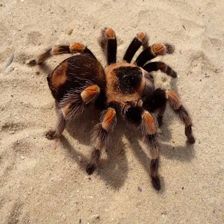

In [56]:
tarantula_dir = ("/content/drive/My Drive/tarantula.jpg")
tarantula = Image.open(tarantula_dir).resize(IMAGE_SHAPE)
tarantula

#**Create Label Dictionary**

In [57]:
tarantula = np.array(tarantula)/255.0
tarantula.shape

(224, 224, 3)

#**predict**

In [58]:
result = classifier.predict(tarantula[np.newaxis, ...])
result.shape

1/1 [==============================] - 0s 58ms/step


(1, 1001)

In [59]:
predicted_class = tf.math.argmax(result[0], axis=-1)
predicted_class

<tf.Tensor: shape=(), dtype=int64, numpy=77>

In [60]:
labels_path = tf.keras.utils.get_file('ImageNetLabels.txt','https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')
imagenet_labels = np.array(open(labels_path).read().splitlines())

In [61]:
imagenet_labels = np.array(open(labels_path).read().splitlines())
predicted_class = tf.math.argmax(result[0], axis=-1)
predicted_label = imagenet_labels[predicted_class]

#**Predicted Label**

In [62]:
print("Predicted Label:", predicted_label)

Predicted Label: tarantula


#**Visualizing Predicted Label**

Text(0.5, 1.0, 'tarantula')

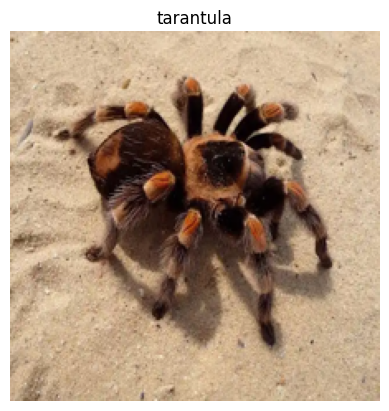

In [63]:
plt.imshow(tarantula)
plt.axis('off')

plt.title(predicted_label)

## Save the Model to Google Drive

In [64]:
model_save_path = '/content/drive/My Drive/Models/Convolutional Nureal Network/Fine-tune MobileNetV2/classifier_model/my_image_classifier.keras'
classifier.save(model_save_path)
print(f"Model saved successfully to: {model_save_path}")

Model saved successfully to: /content/drive/My Drive/Models/Convolutional Nureal Network/Fine-tune MobileNetV2/classifier_model/my_image_classifier.keras
